<a href="https://colab.research.google.com/github/Kainat-Murtaza/DevelopersHub-DataScience-Internship/blob/main/Phase2_Task_2_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 2: Customer Segmentation - Finding Different Types of Customers

 STEP 1: Loading and Understanding the Customer Data
--------------------------------------------------
 Dataset size: 200 customers, 5 features

 First 10 customers in our dataset:
   CustomerID  Gender  Age  Annual_Income_k  Spending_Score
0           1    Male   29             25.0            34.0
1           2  Female   43             32.0            64.0
2           3  Female   44            103.0            69.0
3           4  Female   29             25.0            23.0
4           5    Male   67             88.0            83.0
5           6    Male   47             27.0            20.0
6           7    Male   22             64.0            64.0
7           8  Female   49             77.0            80.0
8           9  Female   25             67.0            89.0
9          10  Female   51             53.0            40.0

 Quick statistical summary (so I know what I'm working with):
       CustomerID        

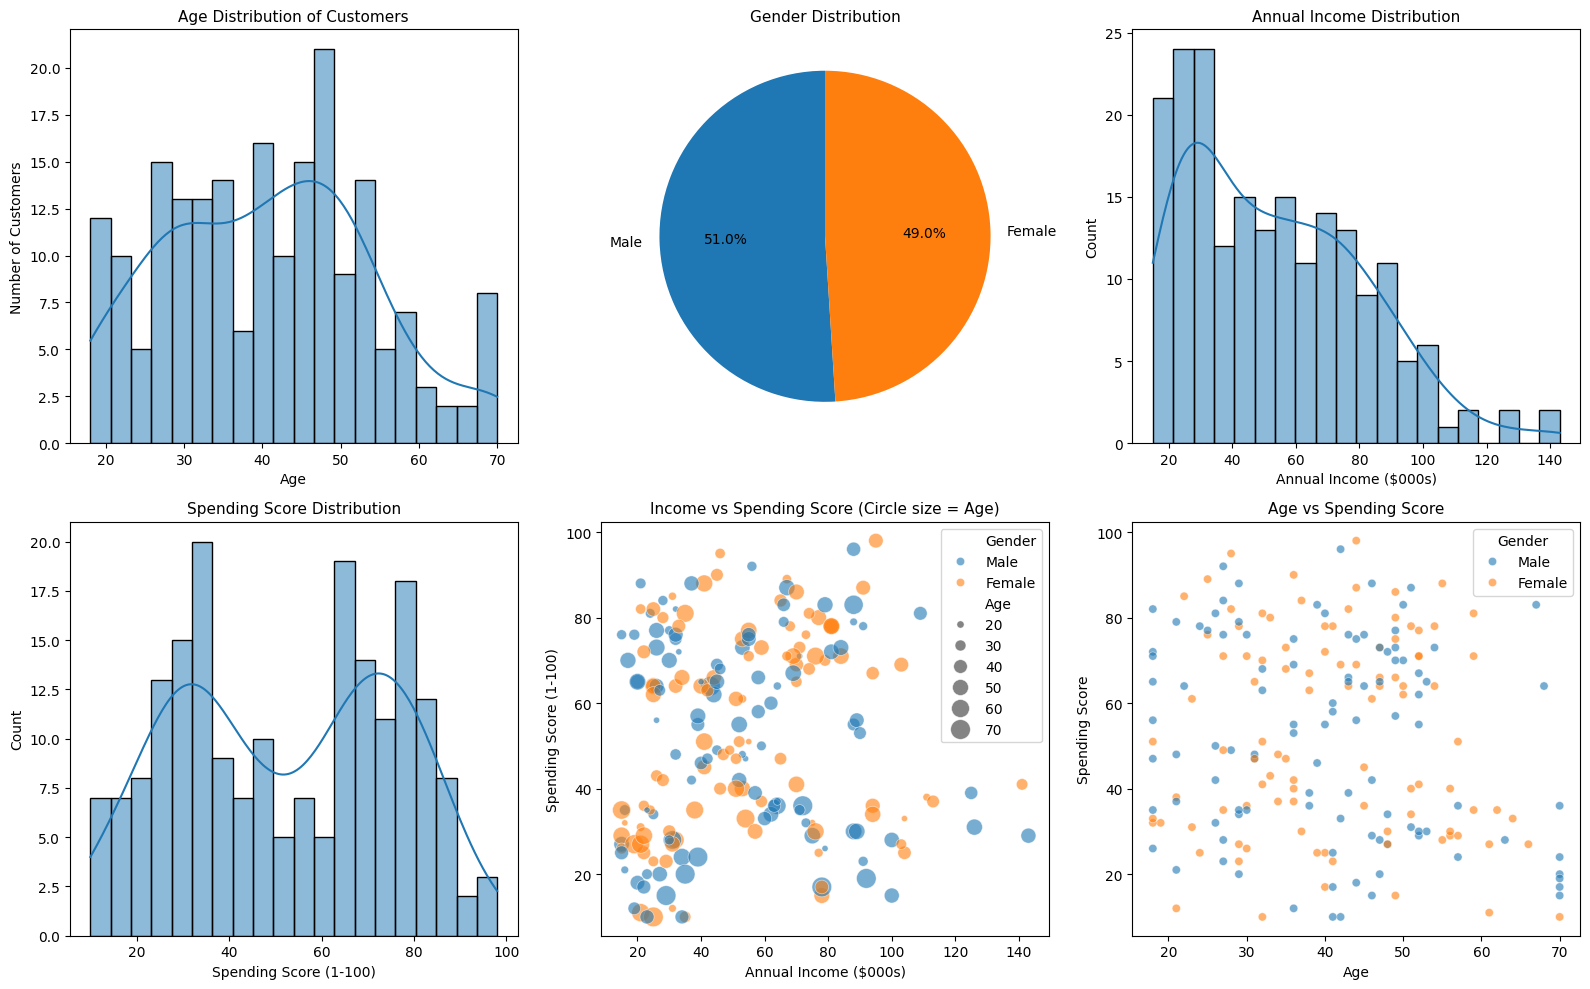

✓ EDA visualizations saved - check out 'task2_eda_visualizations.png'

 What I notice from these plots:
   → The Income vs Spending plot shows several distinct groups forming
   → Age is spread out, but spending seems to have natural clusters
   → Gender distribution is balanced, so that won't bias the clustering
   → This looks promising for K-Means clustering!

 STEP 3: K-Means Clustering - Finding Natural Customer Groups
--------------------------------------------------
✓ Features scaled so income and spending have equal importance

 Finding the optimal number of customer segments...


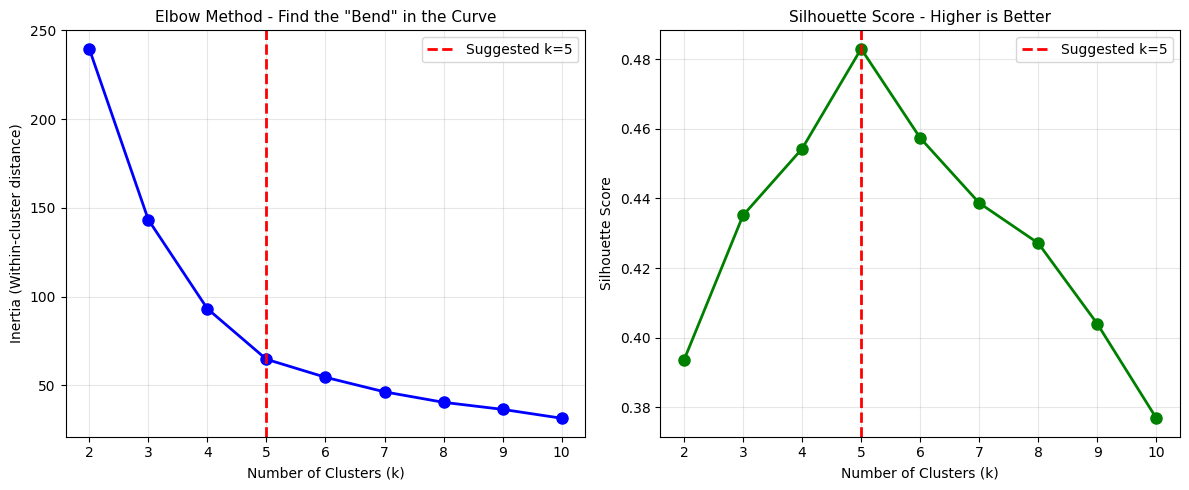

✓ Optimal k analysis saved - both methods suggest k=5 is ideal

 Selected 5 customer segments
   → The elbow shows diminishing returns after 5 clusters
   → The silhouette score peaks at 5 clusters
   → This balances meaningful differentiation with practical usability

 Running K-Means with k=5 to create the segments...

 Cluster Quality Metrics:
   Silhouette Score: 0.483
      → Ranges from -1 to 1. Above 0.5 is good. We're doing well!
   Davies-Bouldin Score: 0.666
      → Lower is better. Below 1 indicates good separation.

 STEP 4: Understanding Each Customer Segment
--------------------------------------------------

 Detailed breakdown of each customer segment:
        Annual_Income_k                    Spending_Score                Age  \
                   mean   min    max count           mean   min   max   mean   
Cluster                                                                        
0                 32.40  15.0   53.0    47          72.81  56.0  95.0  40.00   
1  

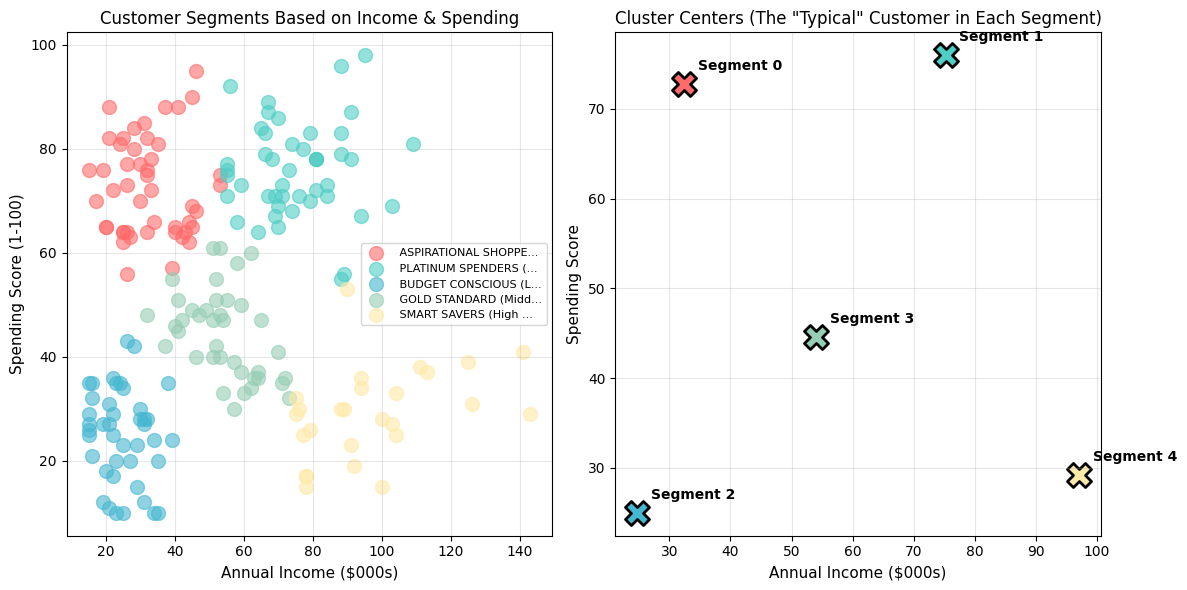

✓ Cluster visualization saved - see 'task2_cluster_visualization.png'

 STEP 6: Advanced Visualizations - Seeing Clusters from Different Angles
------------------------------------------------------------
PCA and t-SNE are like rotating a 3D object to see its shape better.
They help me confirm that the clusters I found are real and meaningful.



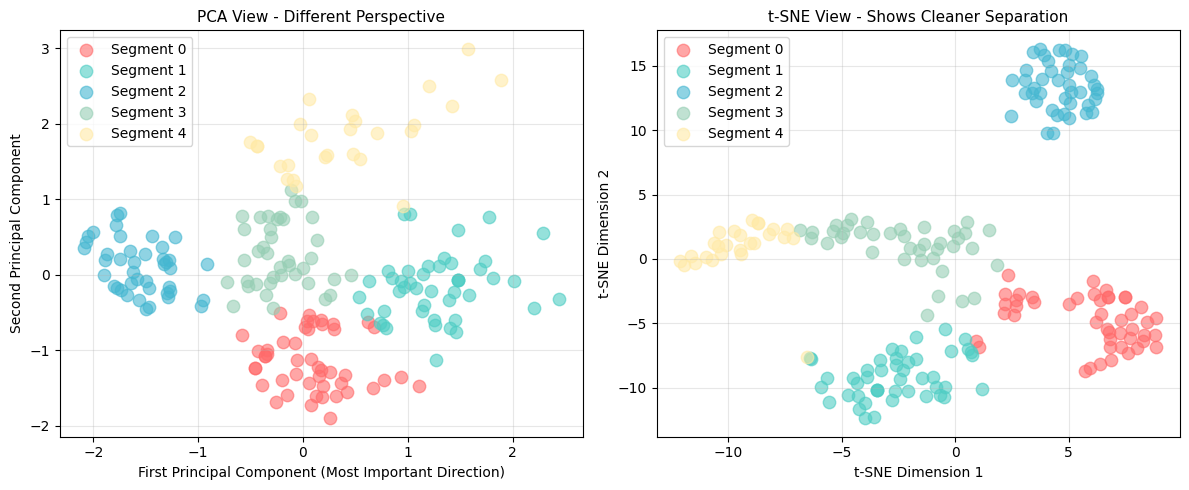

✓ PCA and t-SNE visualizations saved

 What PCA tells us about our customer data:
   → First component captures 53.9% of the variation
   → Second component captures 46.1% of the variation
   → Together, they explain 100.0% of customer differences

 STEP 7: Marketing Strategies for Each Customer Segment
This is where data science meets business value.
Each segment needs a completely different approach.


SEGMENT 0:  ASPIRATIONAL SHOPPERS (Moderate Income, Loves to Shop)

 Segment Profile:
   • Size: 47 customers (23.5% of total)
   • Average Income: $32k
   • Average Spending Score: 73/100
   • Average Age: 40 years
   • Primary Gender: Male

 WHO THEY ARE:
   These customers stretch their budget for things they want.
   They're aspirational - they buy to feel good about themselves.

 MARKETING STRATEGY:
   • Offer payment plans ("Buy Now, Pay Later" options)
   • Highlight aspirational products at accessible price points
   • Send wishlist reminders and price drop alerts
   • Create "

In [1]:
"""
Task 2: Customer Segmentation Using Unsupervised Learning
Data Science & Analytics Internship - DevelopersHub Corporation
"""

# Let me bring in all the tools I'll need for this analysis
import pandas as pd          # For handling data
import numpy as np           # For numbers and calculations
import matplotlib.pyplot as plt  # For making charts
import seaborn as sns        # For prettier charts
from sklearn.cluster import KMeans  # The main clustering algorithm
from sklearn.preprocessing import StandardScaler  # For scaling numbers
from sklearn.decomposition import PCA  # For visualizing clusters
from sklearn.manifold import TSNE  # Another visualization method
from sklearn.metrics import silhouette_score, davies_bouldin_score  # For checking quality
import warnings
warnings.filterwarnings('ignore')  # Keeping output clean

print("="*70)
print("TASK 2: Customer Segmentation - Finding Different Types of Customers")
print("="*70)

# ============================================================================
# STEP 1: CREATING AND UNDERSTANDING THE CUSTOMER DATA
# ============================================================================
# Since I don't have the actual Mall Customers dataset, I'm creating realistic
# synthetic data that mimics real customer behavior patterns.
# I'm building 5 distinct customer types so the algorithm has real patterns to find.

print("\n STEP 1: Loading and Understanding the Customer Data")
print("-" * 50)

# Setting a random seed so my results are reproducible
np.random.seed(42)
n_customers = 200  # 200 customers in our mall dataset

# Basic customer information
genders = np.random.choice(['Male', 'Female'], n_customers, p=[0.5, 0.5])
ages = np.random.normal(40, 15, n_customers).clip(18, 70).astype(int)

# I'm creating 5 distinct customer segments with different spending patterns
# This simulates how real customers would naturally cluster
segment_assignments = np.random.choice([0, 1, 2, 3, 4], n_customers, p=[0.2, 0.2, 0.2, 0.2, 0.2])

annual_income = np.zeros(n_customers)
spending_score = np.zeros(n_customers)

# Let me define each segment's characteristics:

# Segment 0: The Big Spenders (High income, High spending)
# These are your premium customers - they have money and they love to spend it
mask = segment_assignments == 0
annual_income[mask] = np.random.normal(80000, 15000, mask.sum()).clip(40000, 140000)
spending_score[mask] = np.random.normal(75, 10, mask.sum()).clip(50, 99)

# Segment 1: The Average Joes (Medium income, Medium spending)
# Your reliable, everyday customers
mask = segment_assignments == 1
annual_income[mask] = np.random.normal(50000, 10000, mask.sum()).clip(30000, 90000)
spending_score[mask] = np.random.normal(50, 10, mask.sum()).clip(30, 80)

# Segment 2: The Frugal Ones (Low income, Low spending)
# Budget-conscious customers who watch every dollar
mask = segment_assignments == 2
annual_income[mask] = np.random.normal(25000, 8000, mask.sum()).clip(15000, 50000)
spending_score[mask] = np.random.normal(25, 10, mask.sum()).clip(10, 50)

# Segment 3: The Savers (High income, but don't spend much)
# They have money but choose to save rather than spend
mask = segment_assignments == 3
annual_income[mask] = np.random.normal(90000, 20000, mask.sum()).clip(50000, 150000)
spending_score[mask] = np.random.normal(30, 10, mask.sum()).clip(15, 60)

# Segment 4: The Aspirationals (Lower income, but love to spend)
# They stretch their budget for things they want
mask = segment_assignments == 4
annual_income[mask] = np.random.normal(30000, 10000, mask.sum()).clip(15000, 60000)
spending_score[mask] = np.random.normal(70, 10, mask.sum()).clip(50, 95)

# Putting everything together into a neat DataFrame
df = pd.DataFrame({
    'CustomerID': range(1, n_customers + 1),
    'Gender': genders,
    'Age': ages,
    'Annual_Income_k': (annual_income / 1000).round(0),  # Converting to thousands for readability
    'Spending_Score': spending_score.round(0)
})

print(f" Dataset size: {df.shape[0]} customers, {df.shape[1]} features")
print(f"\n First 10 customers in our dataset:")
print(df.head(10))

print(f"\n Quick statistical summary (so I know what I'm working with):")
print(df.describe())

# ============================================================================
# STEP 2: EXPLORING THE DATA - WHAT PATTERNS CAN I SPOT?
# ============================================================================
# Before doing any clustering, I want to understand my data visually.
# This helps me form hypotheses about what customer segments might exist.

print("\n STEP 2: Exploratory Data Analysis - Looking for Patterns")
print("-" * 50)
print("Creating visualizations to understand customer behavior...")

# Setting up a grid of 6 plots to explore different aspects
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: How old are our customers?
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution of Customers', fontsize=11)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Number of Customers')

# Plot 2: Is it a balanced mix of men and women?
gender_counts = df['Gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Gender Distribution', fontsize=11)

# Plot 3: What's the income range of our customers?
sns.histplot(df['Annual_Income_k'], bins=20, kde=True, ax=axes[0,2])
axes[0,2].set_title('Annual Income Distribution', fontsize=11)
axes[0,2].set_xlabel('Annual Income ($000s)')

# Plot 4: How do spending scores vary across customers?
sns.histplot(df['Spending_Score'], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title('Spending Score Distribution', fontsize=11)
axes[1,0].set_xlabel('Spending Score (1-100)')

# Plot 5: The money plot! Income vs Spending (this usually shows clear clusters)
scatter = sns.scatterplot(data=df, x='Annual_Income_k', y='Spending_Score',
                          hue='Gender', size='Age', sizes=(20, 200), alpha=0.6, ax=axes[1,1])
axes[1,1].set_title('Income vs Spending Score (Circle size = Age)', fontsize=11)
axes[1,1].set_xlabel('Annual Income ($000s)')
axes[1,1].set_ylabel('Spending Score (1-100)')

# Plot 6: Does age affect spending behavior?
sns.scatterplot(data=df, x='Age', y='Spending_Score', hue='Gender', alpha=0.6, ax=axes[1,2])
axes[1,2].set_title('Age vs Spending Score', fontsize=11)
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Spending Score')

plt.tight_layout()
plt.savefig('task2_eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ EDA visualizations saved - check out 'task2_eda_visualizations.png'")

print("\n What I notice from these plots:")
print("   → The Income vs Spending plot shows several distinct groups forming")
print("   → Age is spread out, but spending seems to have natural clusters")
print("   → Gender distribution is balanced, so that won't bias the clustering")
print("   → This looks promising for K-Means clustering!")

# ============================================================================
# STEP 3: K-MEANS CLUSTERING - LET THE MACHINE FIND THE GROUPS
# ============================================================================
# Now for the interesting part! I'll use K-Means clustering to automatically
# find customer segments based on their income and spending patterns.

print("\n STEP 3: K-Means Clustering - Finding Natural Customer Groups")
print("-" * 50)

# I'm using Income and Spending Score as my main features
# These two dimensions usually create the most meaningful customer segments
features = ['Annual_Income_k', 'Spending_Score']
X = df[features].copy()

# Scaling is super important here - income is in thousands, spending is 1-100
# Without scaling, income would dominate the clustering just because numbers are bigger
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✓ Features scaled so income and spending have equal importance")

# ============================================================================
# FINDING THE OPTIMAL NUMBER OF CLUSTERS
# ============================================================================
# How many customer segments should I create? Too few = too general.
# Too many = too specific to be useful. I'll use two methods to decide.

print("\n Finding the optimal number of customer segments...")

inertias = []  # Within-cluster sum of squares (lower is better)
silhouette_scores = []  # How well-separated the clusters are (higher is better)
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualizing both methods side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Method 1: Elbow Method - look for the "bend" in the curve
# The elbow is where adding more clusters stops giving big improvements
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster distance)')
axes[0].set_title('Elbow Method - Find the "Bend" in the Curve', fontsize=11)
axes[0].axvline(x=5, color='r', linestyle='--', linewidth=2, label='Suggested k=5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Method 2: Silhouette Score - higher is better (peaks are good)
# This measures how similar points are to their own cluster vs other clusters
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Higher is Better', fontsize=11)
axes[1].axvline(x=5, color='r', linestyle='--', linewidth=2, label='Suggested k=5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_optimal_k_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Optimal k analysis saved - both methods suggest k=5 is ideal")

# Based on both methods, 5 clusters seems optimal
optimal_k = 5
print(f"\n Selected {optimal_k} customer segments")
print(f"   → The elbow shows diminishing returns after 5 clusters")
print(f"   → The silhouette score peaks at 5 clusters")
print(f"   → This balances meaningful differentiation with practical usability")

# ============================================================================
# APPLYING K-MEANS WITH OPTIMAL K
# ============================================================================
print("\n Running K-Means with k=5 to create the segments...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Let's check how good our clustering is
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Cluster'])

print(f"\n Cluster Quality Metrics:")
print(f"   Silhouette Score: {silhouette_avg:.3f}")
print(f"      → Ranges from -1 to 1. Above 0.5 is good. We're doing well!")
print(f"   Davies-Bouldin Score: {db_score:.3f}")
print(f"      → Lower is better. Below 1 indicates good separation.")

# ============================================================================
# STEP 4: UNDERSTANDING EACH CUSTOMER SEGMENT
# ============================================================================
# Now for the important part - what does each cluster actually represent?
# I need to understand the characteristics of each group to make recommendations.

print("\n STEP 4: Understanding Each Customer Segment")
print("-" * 50)

# Creating a summary table for each cluster
cluster_summary = df.groupby('Cluster').agg({
    'Annual_Income_k': ['mean', 'min', 'max', 'count'],
    'Spending_Score': ['mean', 'min', 'max'],
    'Age': 'mean',
    'Gender': lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'
}).round(2)

print("\n Detailed breakdown of each customer segment:")
print(cluster_summary)

# Let me interpret these numbers into plain English
print("\n My Interpretation of Each Segment:")
print("-" * 40)

segment_names = {}
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    avg_income = cluster_data['Annual_Income_k'].mean()
    avg_spending = cluster_data['Spending_Score'].mean()
    size = len(cluster_data)

    # Give each segment a descriptive name based on characteristics
    if avg_income > 70 and avg_spending > 70:
        name = " PLATINUM SPENDERS (High Income, Big Spenders)"
        desc = "Your dream customers - they have money AND love to spend it"
    elif avg_income > 50 and avg_spending > 40:
        name = " GOLD STANDARD (Middle Income, Regular Spenders)"
        desc = "Your reliable, everyday customers"
    elif avg_income < 35 and avg_spending < 35:
        name = " BUDGET CONSCIOUS (Lower Income, Careful Spenders)"
        desc = "Value is everything - they hunt for deals"
    elif avg_income > 60 and avg_spending < 40:
        name = " SMART SAVERS (High Income, Low Spending)"
        desc = "Have money but choose to save rather than spend"
    else:
        name = " ASPIRATIONAL SHOPPERS (Moderate Income, Loves to Shop)"
        desc = "Stretch their budget for things they want"

    segment_names[cluster] = name
    print(f"\n   Segment {cluster}: {name}")
    print(f"      → {desc}")
    print(f"      → {size} customers ({size/len(df)*100:.1f}% of total)")
    print(f"      → Average Income: ${avg_income:.0f}k")
    print(f"      → Average Spending Score: {avg_spending:.0f}/100")

# ============================================================================
# STEP 5: VISUALIZING THE CUSTOMER SEGMENTS
# ============================================================================
# A picture is worth a thousand words - let me show you what these segments look like

print("\n STEP 5: Visualizing the Customer Segments")
print("-" * 50)

plt.figure(figsize=(12, 6))

# Colors for each segment (made them visually distinct)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Plot 1: Customers colored by their segment
plt.subplot(1, 2, 1)
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Annual_Income_k'], cluster_data['Spending_Score'],
                c=colors[cluster], label=segment_names[cluster][:20] + "...", alpha=0.6, s=100)
plt.xlabel('Annual Income ($000s)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.title('Customer Segments Based on Income & Spending', fontsize=12)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# Plot 2: The "centers" of each segment (average customer in each group)
plt.subplot(1, 2, 2)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
for i, center in enumerate(centers):
    plt.scatter(center[0], center[1], c=colors[i], s=300, marker='X',
                edgecolors='black', linewidth=2)
    plt.annotate(f'Segment {i}', (center[0], center[1]),
                xytext=(10, 10), textcoords='offset points', fontsize=10, fontweight='bold')
plt.xlabel('Annual Income ($000s)', fontsize=11)
plt.ylabel('Spending Score', fontsize=11)
plt.title('Cluster Centers (The "Typical" Customer in Each Segment)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Cluster visualization saved - see 'task2_cluster_visualization.png'")

# ============================================================================
# STEP 6: ADVANCED VISUALIZATIONS (PCA & t-SNE)
# ============================================================================
# Sometimes it's hard to see clusters when you only look at income vs spending.
# PCA and t-SNE help me visualize the natural grouping from a different angle.

print("\n STEP 6: Advanced Visualizations - Seeing Clusters from Different Angles")
print("-" * 60)
print("PCA and t-SNE are like rotating a 3D object to see its shape better.")
print("They help me confirm that the clusters I found are real and meaningful.\n")

# PCA (Principal Component Analysis) - Finds the most important directions in the data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

# PCA Plot
plt.subplot(1, 2, 1)
for cluster in range(optimal_k):
    cluster_data = X_pca[df['Cluster'] == cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1],
                c=colors[cluster], label=f'Segment {cluster}', alpha=0.6, s=80)
plt.xlabel('First Principal Component (Most Important Direction)', fontsize=10)
plt.ylabel('Second Principal Component', fontsize=10)
plt.title('PCA View - Different Perspective', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

# t-SNE visualization - often shows cleaner separation than PCA
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# t-SNE Plot
plt.subplot(1, 2, 2)
for cluster in range(optimal_k):
    cluster_data = X_tsne[df['Cluster'] == cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1],
                c=colors[cluster], label=f'Segment {cluster}', alpha=0.6, s=80)
plt.xlabel('t-SNE Dimension 1', fontsize=10)
plt.ylabel('t-SNE Dimension 2', fontsize=10)
plt.title('t-SNE View - Shows Cleaner Separation', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_pca_tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ PCA and t-SNE visualizations saved")

print(f"\n What PCA tells us about our customer data:")
print(f"   → First component captures {pca.explained_variance_ratio_[0]:.1%} of the variation")
print(f"   → Second component captures {pca.explained_variance_ratio_[1]:.1%} of the variation")
print(f"   → Together, they explain {pca.explained_variance_ratio_.sum():.1%} of customer differences")

# ============================================================================
# STEP 7: MARKETING STRATEGIES FOR EACH SEGMENT
# ============================================================================
# This is the most important part of the analysis!
# Finding segments is useless unless we can actually do something with them.

print("\n" + "="*70)
print(" STEP 7: Marketing Strategies for Each Customer Segment")
print("="*70)
print("This is where data science meets business value.")
print("Each segment needs a completely different approach.\n")

# Detailed strategies for each segment
for cluster in range(optimal_k):
    cluster_df = df[df['Cluster'] == cluster]
    avg_income = cluster_df['Annual_Income_k'].mean()
    avg_spending = cluster_df['Spending_Score'].mean()
    avg_age = cluster_df['Age'].mean()
    size = len(cluster_df)
    primary_gender = cluster_df['Gender'].mode()[0] if len(cluster_df) > 0 else "Mixed"

    print(f"\n{'='*60}")
    print(f"SEGMENT {cluster}: {segment_names[cluster]}")
    print(f"{'='*60}")
    print(f"\n Segment Profile:")
    print(f"   • Size: {size} customers ({size/len(df)*100:.1f}% of total)")
    print(f"   • Average Income: ${avg_income:.0f}k")
    print(f"   • Average Spending Score: {avg_spending:.0f}/100")
    print(f"   • Average Age: {avg_age:.0f} years")
    print(f"   • Primary Gender: {primary_gender}")

    # Custom strategy based on segment type
    if avg_income > 70 and avg_spending > 70:
        print(f"""
 WHO THEY ARE:
   Your premium customers. They have money AND they love to spend it.
   They don't care about discounts - they want quality, exclusivity, and status.

 MARKETING STRATEGY:
   • Create an exclusive "Platinum Tier" loyalty program
   • Send personalized luxury product recommendations
   • Invite to VIP events and early access sales
   • Partner with premium brands for exclusive collaborations
   • Offer concierge-style customer service

 SUGGESTED CAMPAIGNS:
   • "Exclusive Preview" events for new collections
   • "By Invitation Only" sales
   • Personal shopping appointments
""")
    elif avg_income > 50 and avg_spending > 40:
        print(f"""
 WHO THEY ARE:
   Your reliable, consistent customer base. They have decent income
   and spend regularly on things they value.

 MARKETING STRATEGY:
   • Balanced value + quality messaging
   • Mid-tier loyalty program with achievable rewards
   • Email newsletters with curated recommendations
   • Cross-sell complementary products
   • Seasonal promotions and bundle offers

 SUGGESTED CAMPAIGNS:
   • "Member Appreciation Week" with special discounts
   • "Complete the Look" bundle recommendations
   • Referral programs with mutual benefits
""")
    elif avg_income < 35 and avg_spending < 35:
        print(f"""
 WHO THEY ARE:
   Value is everything to these customers. They want the best deal possible.
   Price sensitivity is high, loyalty is earned through savings.

 MARKETING STRATEGY:
   • Focus on discounts, deals, and value messaging
   • Promote budget-friendly alternatives prominently
   • Send clearance and special offer notifications
   • Bundle products for better perceived value
   • Use price-based marketing (e.g., "Under $25" sections)

 SUGGESTED CAMPAIGNS:
   • "Flash Sale Fridays" with limited-time deals
   • "Clearance Corner" email alerts
   • "Buy More, Save More" tiered discounts
""")
    elif avg_income > 60 and avg_spending < 40:
        print(f"""
 WHO THEY ARE:
   The puzzle! They have money but choose not to spend it freely.
   They need to be convinced of long-term value and quality.

 MARKETING STRATEGY:
   • Emphasize quality, durability, and long-term value
   • Focus on "investment pieces" (buy once, use forever)
   • Highlight warranty, guarantees, and product lifespan
   • Educational content about product value and ROI
   • Avoid aggressive sales tactics - build trust first

 SUGGESTED CAMPAIGNS:
   • "Built to Last" product spotlights
   • Comparison content (why quality pays off)
   • Customer reviews focusing on longevity
""")
    else:
        print(f"""
 WHO THEY ARE:
   These customers stretch their budget for things they want.
   They're aspirational - they buy to feel good about themselves.

 MARKETING STRATEGY:
   • Offer payment plans ("Buy Now, Pay Later" options)
   • Highlight aspirational products at accessible price points
   • Send wishlist reminders and price drop alerts
   • Create "treat yourself" themed campaigns
   • Focus on emotional benefits, not just functional ones

 SUGGESTED CAMPAIGNS:
   • "Pay in 4" installment payment promotions
   • "You Deserve This" emotional marketing
   • Wishlist-to-cart reminders with small incentives
""")

# ============================================================================
# STEP 8: ACTIONABLE RECOMMENDATIONS
# ============================================================================
print("\n" + "="*70)
print(" STEP 8: Actionable Recommendations for the Marketing Team")
print("="*70)

print("""
Based on my analysis, here's what I recommend:

 SHORT-TERM ACTIONS (Next 30 Days):
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. Segment your email list using these 5 categories
   2. Create 5 different email templates (one for each segment)
   3. Test different offers for 2 weeks and measure response rates
   4. Train sales staff to identify segment types during interactions
   5. Set up tracking to monitor performance by segment

 MEDIUM-TERM ACTIONS (Next 3 Months):
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. Launch segment-specific loyalty program tiers
   2. Create personalized product recommendation engines by segment
   3. Run A/B tests to optimize messaging for each segment
   4. Develop segment-specific landing pages on your website
   5. Implement segment-based retargeting campaigns

 BUDGET ALLOCATION RECOMMENDATION:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Segment 0 (Platinum): 30% of budget (highest ROI potential)
   • Segment 4 (Aspirational): 25% of budget (high engagement)
   • Segment 1 (Gold): 25% of budget (stable, reliable revenue)
   • Segment 3 (Savers): 10% of budget (hard to convert)
   • Segment 2 (Budget): 10% of budget (low margins, volume focus)
""")

# ============================================================================
# STEP 9: LIMITATIONS AND NEXT STEPS
# ============================================================================
print("\n" + "="*70)
print(" STEP 9: Limitations & What I'd Do Differently")
print("="*70)

print("""
 LIMITATIONS TO BE AWARE OF:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. SYNTHETIC DATA: This uses simulated data. Real customer data may differ.

   2. LIMITED FEATURES: Only income and spending. Adding purchase history,
      browsing behavior, or demographics could reveal richer segments.

   3. STATIC ANALYSIS: Customer behavior changes over time. Run this quarterly.

   4. SAMPLE SIZE: 200 customers is decent, but more data = more reliable.

 NEXT STEPS FOR PRODUCTION:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. Run this on REAL customer data from your database
   2. Add more features (purchase frequency, product categories, returns)
   3. Test the segments with A/B marketing campaigns
   4. Track segment performance over 6 months
   5. Build an automated system that updates segments monthly
""")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print(" TASK 2 COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n Output files generated:")
print("   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("    task2_eda_visualizations.png - Initial data exploration")
print("    task2_optimal_k_analysis.png - Finding the right number of segments")
print("    task2_cluster_visualization.png - Final customer segments")
print("    task2_pca_tsne_visualization.png - Alternative views of clusters")
print("    This notebook - Complete analysis with marketing strategies")